![banner](../../../docs/figs/brand_identity/banner.png)

# Week 2: Visualizing CNN Feature Maps

## Lesson overview

First train a small convolutional network on the Fashion-MNIST images included in the repository, then inspect its internal feature maps. The inputs are grayscale clothing images and labels; the outputs are predicted classes and the responses learned by each layer.

**By the end, you can:** distinguish data preparation from model training; describe what a feature map shows; and compare responses to different clothing images.

**Before you begin:** Run cells from top to bottom. The data is included in the repository, so no data download is needed. Training takes some time. The comparison figure is saved in the output folder set by `OUTPUT_DIR`.

## Step 1: Load and prepare the Fashion-MNIST data

This step reads the local image files, pairs each image with its clothing label, and makes batches for training and validation. The output is prepared data; no model is trained yet. Run this cell before moving on.

**Check:** the training and validation loaders should be ready, and the test set remains separate for later checks.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from datasets import load_dataset
from torch.utils.data import Dataset
from pathlib import Path
from ccai9012.paths import ensure_output_dir
OUTPUT_DIR = ensure_output_dir(Path.cwd())


In [14]:
import gzip
import struct
from types import SimpleNamespace
from PIL import Image
from ccai9012.paths import DATA_DIR

LABEL_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
class FashionIDX:
    """Read the repository's compressed Fashion-MNIST IDX files."""
    def __init__(self, image_file, label_file):
        with gzip.open(image_file, "rb") as f:
            _, self.count, self.rows, self.cols = struct.unpack(">IIII", f.read(16))
            self.images = f.read()
        with gzip.open(label_file, "rb") as f:
            _, label_count = struct.unpack(">II", f.read(8))
            self.labels = f.read()
        if self.count != label_count:
            raise ValueError("Fashion-MNIST image and label counts differ")
        self.features = {"label": SimpleNamespace(names=LABEL_NAMES)}
    def __len__(self):
        return self.count
    def __getitem__(self, idx):
        start = idx * self.rows * self.cols
        pixels = self.images[start:start + self.rows * self.cols]
        return {"image": Image.frombytes("L", (self.cols, self.rows), pixels), "label": self.labels[idx]}

# Use the Fashion-MNIST files bundled with this repository.
FASHION_DIR = DATA_DIR / "fashion"
# Keep the provided training and test images in separate groups.
dataset = {
    "train": FashionIDX(FASHION_DIR / "train-images-idx3-ubyte.gz", FASHION_DIR / "train-labels-idx1-ubyte.gz"),
    "test": FashionIDX(FASHION_DIR / "t10k-images-idx3-ubyte.gz", FASHION_DIR / "t10k-labels-idx1-ubyte.gz"),
}


# Convert each local sample to the tensor/label pair used by PyTorch.
# Convert pixels to tensors and put their values on a consistent scale.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

class FashionDataset(Dataset):
    def __init__(self, source, transform=None):
        self.source = source
        self.transform = transform
    def __len__(self):
        return len(self.source)
    def __getitem__(self, idx):
        record = self.source[idx]
        image = record["image"]
        if self.transform:
            image = self.transform(image)
        return image, int(record["label"])

full_train_dataset = FashionDataset(dataset["train"], transform=transform)
test_dataset = FashionDataset(dataset["test"], transform=transform)
# Set aside part of the training data to check progress during training.
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)
# Load the data in small groups; shuffle training examples between passes.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
print(f"Train: {len(train_dataset):,}; validation: {len(val_dataset):,}; test: {len(test_dataset):,}")


Train: 48,000; validation: 12,000; test: 10,000


## Step 2: Train a small CNN model

Now define the network, choose the training settings, and fit it using the batches from Step 1. The model takes a 28×28 image and returns scores for ten clothing labels.

Run the model-definition and training cells in order. Training may take a few minutes. The loss values show how far predictions are from the known labels; lower values are useful only when validation loss also behaves well.

In [15]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                         
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                         
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
# Set up training configuration
# Use a supported graphics processor when available, otherwise use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

# CrossEntropyLoss applies softmax + loss in one step
# Compare the ten class scores with the correct clothing label.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Add a global list to store training loss per epoch
train_losses = []

# Model training function
def train_model(num_epochs=5):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        # Each batch contains pictures and their correct labels.
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            # Work out how each model setting contributed to the error.
            loss.backward()
            # Adjust the model to reduce the error on later batches.
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

In [17]:
# Train the model
train_model()

Epoch 1, Loss: 0.4650
Epoch 2, Loss: 0.2993
Epoch 3, Loss: 0.2508
Epoch 4, Loss: 0.2203
Epoch 5, Loss: 0.1920


## Step 3: Record what one convolution layer sees

A hook is a small observer attached to a chosen layer. It saves that layer’s output while the model processes an image; it does not change the model.

**Input:** the trained model. **Output:** saved feature maps for the next visualization steps.

In [6]:
# Register a hook to capture the feature map of the second convolutional layer (self.model[3])
# The hooks below store layer outputs here while an image passes through.
feature_maps = {}
def hook_fn_conv1(module, input, output):
    feature_maps['conv1'] = output.detach()

def hook_fn_conv2(module, input, output):
    feature_maps['conv2'] = output.detach()

hook_handle1 = model.model[0].register_forward_hook(hook_fn_conv1)
hook_handle2 = model.model[3].register_forward_hook(hook_fn_conv2)

## Step 4: Show feature maps for one image

Choose one test image and pass it through the trained model. The original image shows the clothing item; each feature map shows where one learned filter responded strongly. Bright areas mean a stronger response, not a named object part.

In [7]:
# Run a forward pass on a single test image to trigger the hook and capture the feature map
model.eval()
with torch.no_grad():
    # Choose one held-out test image and its known label.
    img, label = test_dataset[10]
    img_batch = img.unsqueeze(0).to(device)  # Add batch dimension and send to device
    output = model(img_batch)  # Forward pass (output ignored here)

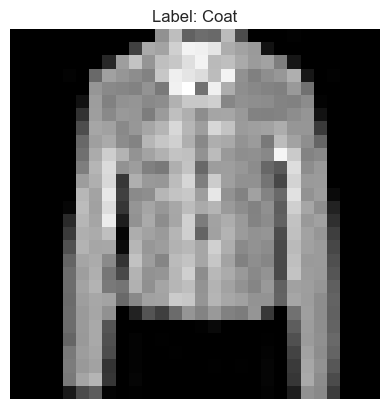

In [8]:
class_names = dataset['train'].features['label'].names

def imshow(img_tensor):
    img = img_tensor * 0.5 + 0.5 
    img = img.clamp(0, 1)
    np_img = img.squeeze().cpu().numpy()
    plt.imshow(np_img, cmap='gray')
    plt.axis('off')

plt.figure()
imshow(img)
plt.title(f'Label: {class_names[label]}')
plt.show()

In [9]:
def visualize_feature_maps(features, mode='individual'):
    """
    Visualize feature maps with options for individual channels or aggregated map.
    
    Args:
        features: Tensor of shape [batch, channels, height, width]
        mode: 'individual' to plot each channel separately (default)
              'mean' to plot mean aggregated map over channels
              'max' to plot max aggregated map over channels
    """
    if mode == 'individual':
        num_channels = features.shape[1]
        cols = 8
        rows = (num_channels + cols - 1) // cols
        plt.figure(figsize=(cols*2, rows*2))
        for i in range(num_channels):
            plt.subplot(rows, cols, i+1)
            plt.imshow(features[0, i].cpu(), cmap='viridis')
            plt.axis('off')
            plt.title(f'ch{i}')
        plt.suptitle('Feature maps of conv layer (individual channels)')
        plt.show()
    
    elif mode == 'mean':
        # Average channel responses into one summary image.
        aggregated_map = features.mean(dim=1)[0].cpu()  # Mean over channels
        plt.figure(figsize=(6,6))
        plt.imshow(aggregated_map, cmap='viridis')
        plt.colorbar()
        plt.title('Mean aggregated feature map of conv layer')
        plt.axis('off')
        plt.show()
    
    elif mode == 'max':
        # Keep the strongest channel response at each image location.
        aggregated_map = features.max(dim=1)[0][0].cpu()  # Max over channels
        plt.figure(figsize=(6,6))
        plt.imshow(aggregated_map, cmap='viridis')
        plt.colorbar()
        plt.title('Max aggregated feature map of conv layer')
        plt.axis('off')
        plt.show()

    else:
        raise ValueError("Invalid mode! Choose from 'individual', 'mean', or 'max'.")

Feature map of Conv1 Layer (Individual channels)


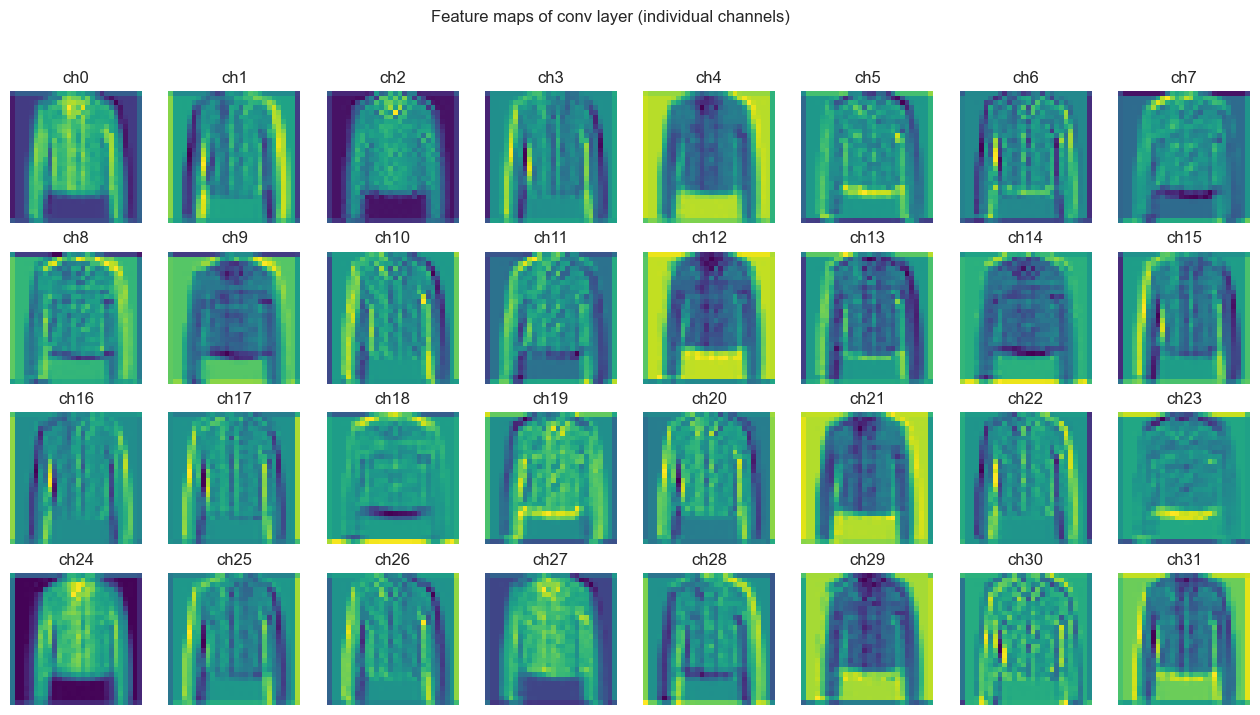

Feature map of Conv2 Layer (Individual channels)


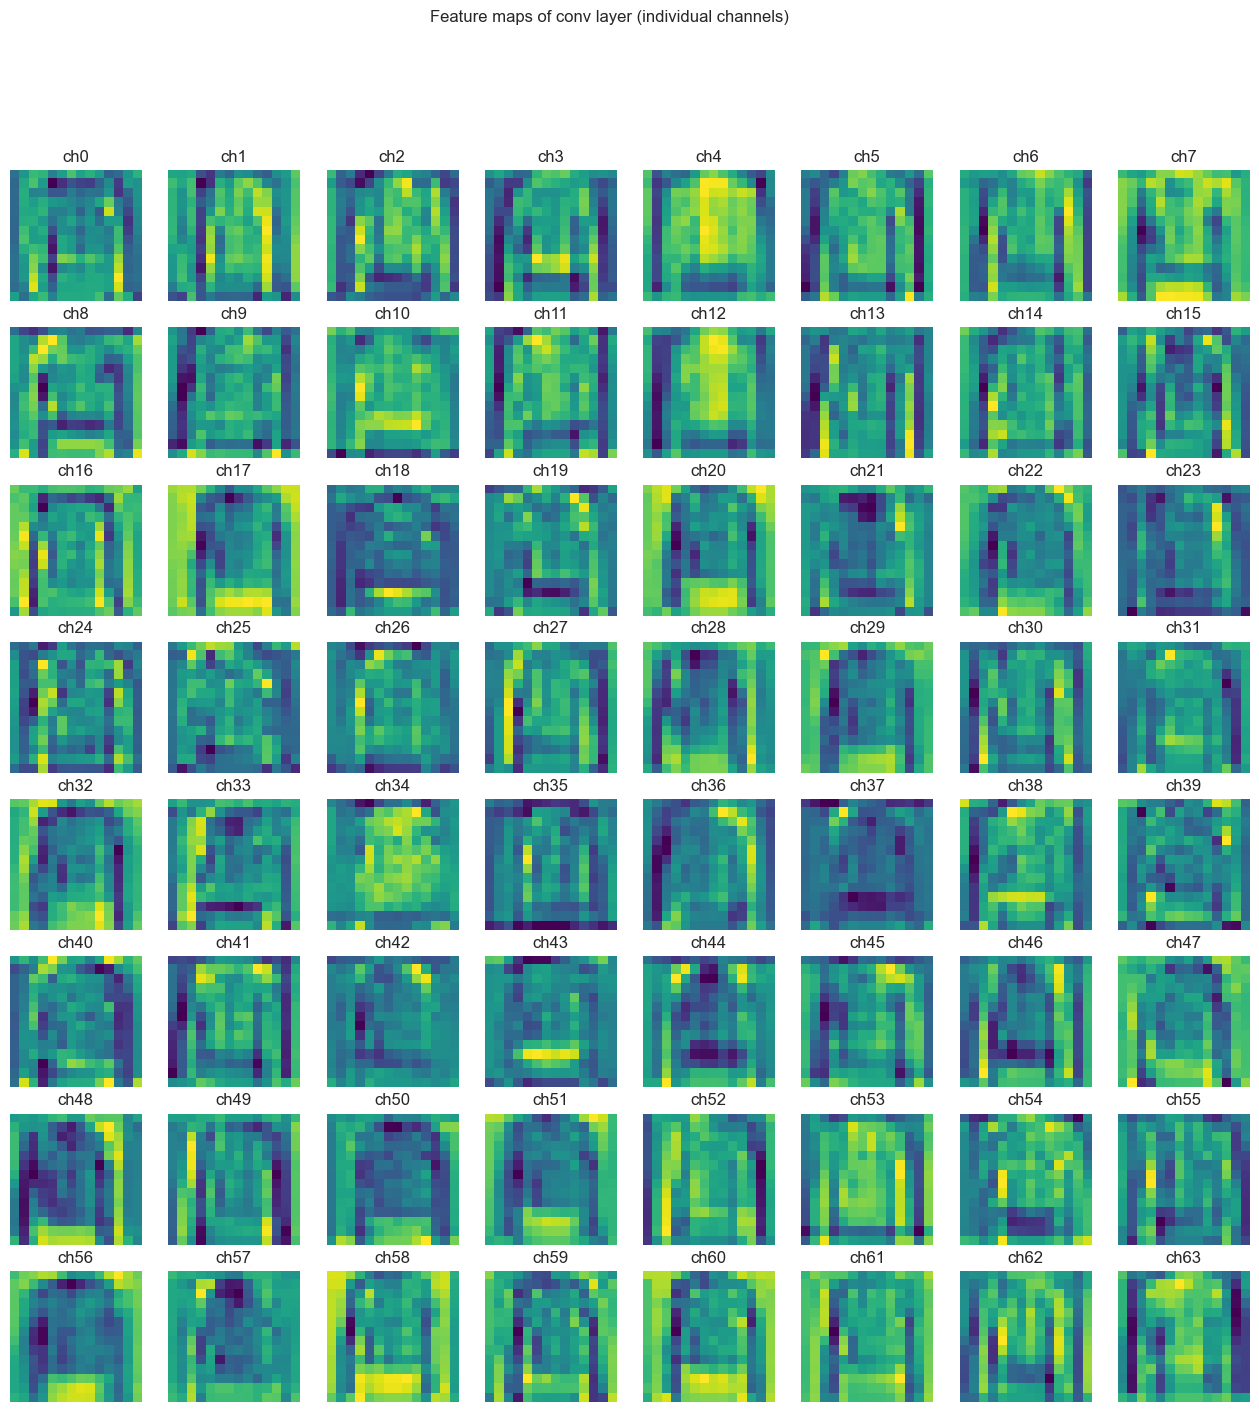

In [10]:
# Visualize the feature maps collected by the hook
print("Feature map of Conv1 Layer (Individual channels)")
visualize_feature_maps(feature_maps['conv1'], mode='individual')
print("Feature map of Conv2 Layer (Individual channels)")
visualize_feature_maps(feature_maps['conv2'], mode='individual')

# Remove the hook after visualization to avoid side effects



Feature map of Conv1 Layer (Mean Aggregated Map)


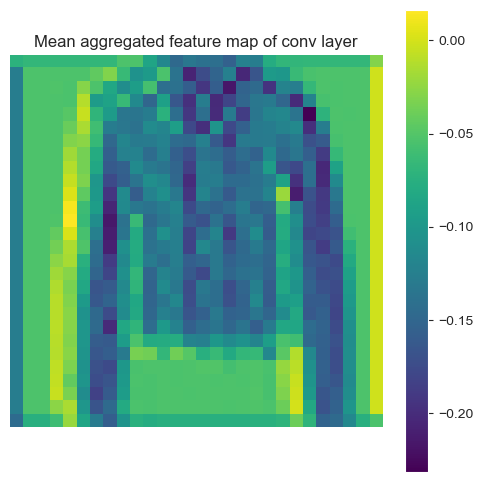

Feature map of Conv2 Layer (Mean Aggregated Map)


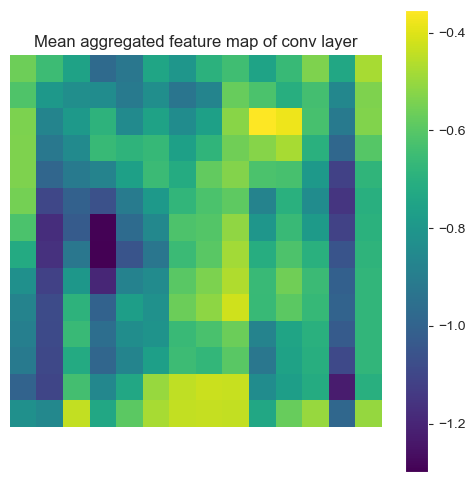

In [11]:
# Visualize the feature maps collected by the hook
print("Feature map of Conv1 Layer (Mean Aggregated Map)")
visualize_feature_maps(feature_maps['conv1'], mode='mean')
print("Feature map of Conv2 Layer (Mean Aggregated Map)")
visualize_feature_maps(feature_maps['conv2'], mode='mean')

# Remove the hook after visualization to avoid side effects



Feature map of Conv1 Layer (Max Aggregated Map)


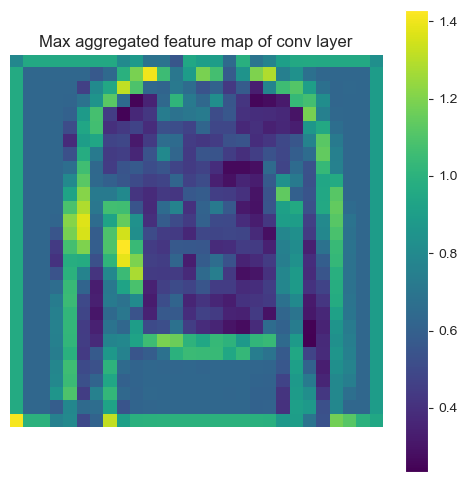

Feature map of Conv2 Layer (Max Aggregated Map)


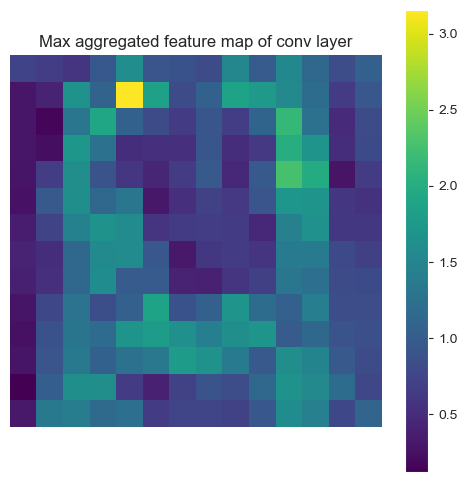

In [12]:
# Visualize the feature maps collected by the hook
print("Feature map of Conv1 Layer (Max Aggregated Map)")
visualize_feature_maps(feature_maps['conv1'], mode='max')
print("Feature map of Conv2 Layer (Max Aggregated Map)")
visualize_feature_maps(feature_maps['conv2'], mode='max')

# Remove the hook after visualization to avoid side effects



## Step 5: Compare images from different clothing classes

The comparison uses one or more test images per label and saves a figure to `OUTPUT_DIR / "feature_map_comparison.png"`. Compare broad patterns across rows; a feature map is an internal response, not a direct explanation of the model’s decision.

In [13]:
def visualize_feature_maps_both_layers(model, dataset, label_names, samples_per_class=1, device='cpu'):
    """
    Visualize input images with mean/max aggregated feature maps from conv1 and conv2 layers.

    Args:
        model: trained model with registered hooks for 'conv1' and 'conv2'
        dataset: test dataset (e.g., test_dataset)
        label_names: list of class names (length 10)
        samples_per_class: number of samples to visualize per class
        device: torch device
    """
    model.eval()
    shown = {i: 0 for i in range(10)}
    selected = []

    # Select samples_per_class per label
    for img, label in dataset:
        if shown[label] < samples_per_class:
            selected.append((img, label))
            shown[label] += 1
        if sum(shown.values()) >= 10 * samples_per_class:
            break

    num_samples = len(selected)
    plt.figure(figsize=(15, num_samples * 3))

    for i, (img, label) in enumerate(selected):
        img_batch = img.unsqueeze(0).to(device)

        # Forward pass to trigger hooks
        with torch.no_grad():
            _ = model(img_batch)

        # --- Original image ---
        plt.subplot(num_samples, 5, i*5 + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f'Label: {label_names[label]}')
        plt.axis('off')

        # --- Conv1 mean ---
        mean_map1 = feature_maps['conv1'].mean(dim=1)[0].cpu()
        plt.subplot(num_samples, 5, i*5 + 2)
        plt.imshow(mean_map1, cmap='viridis')
        plt.title('Conv1 Mean')
        plt.axis('off')

        # --- Conv1 max ---
        max_map1 = feature_maps['conv1'].max(dim=1)[0][0].cpu()
        plt.subplot(num_samples, 5, i*5 + 3)
        plt.imshow(max_map1, cmap='viridis')
        plt.title('Conv1 Max')
        plt.axis('off')

        # --- Conv2 mean ---
        mean_map2 = feature_maps['conv2'].mean(dim=1)[0].cpu()
        plt.subplot(num_samples, 5, i*5 + 4)
        plt.imshow(mean_map2, cmap='viridis')
        plt.title('Conv2 Mean')
        plt.axis('off')

        # --- Conv2 max ---
        max_map2 = feature_maps['conv2'].max(dim=1)[0][0].cpu()
        plt.subplot(num_samples, 5, i*5 + 5)
        plt.imshow(max_map2, cmap='viridis')
        plt.title('Conv2 Max')
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle('Feature Map Visualization: Original + Conv1/Conv2 Aggregations', fontsize=16, y=1.03)
    # Save the comparison figure in the course output folder.
    plt.savefig(OUTPUT_DIR / "feature_map_comparison.png")
    plt.show()

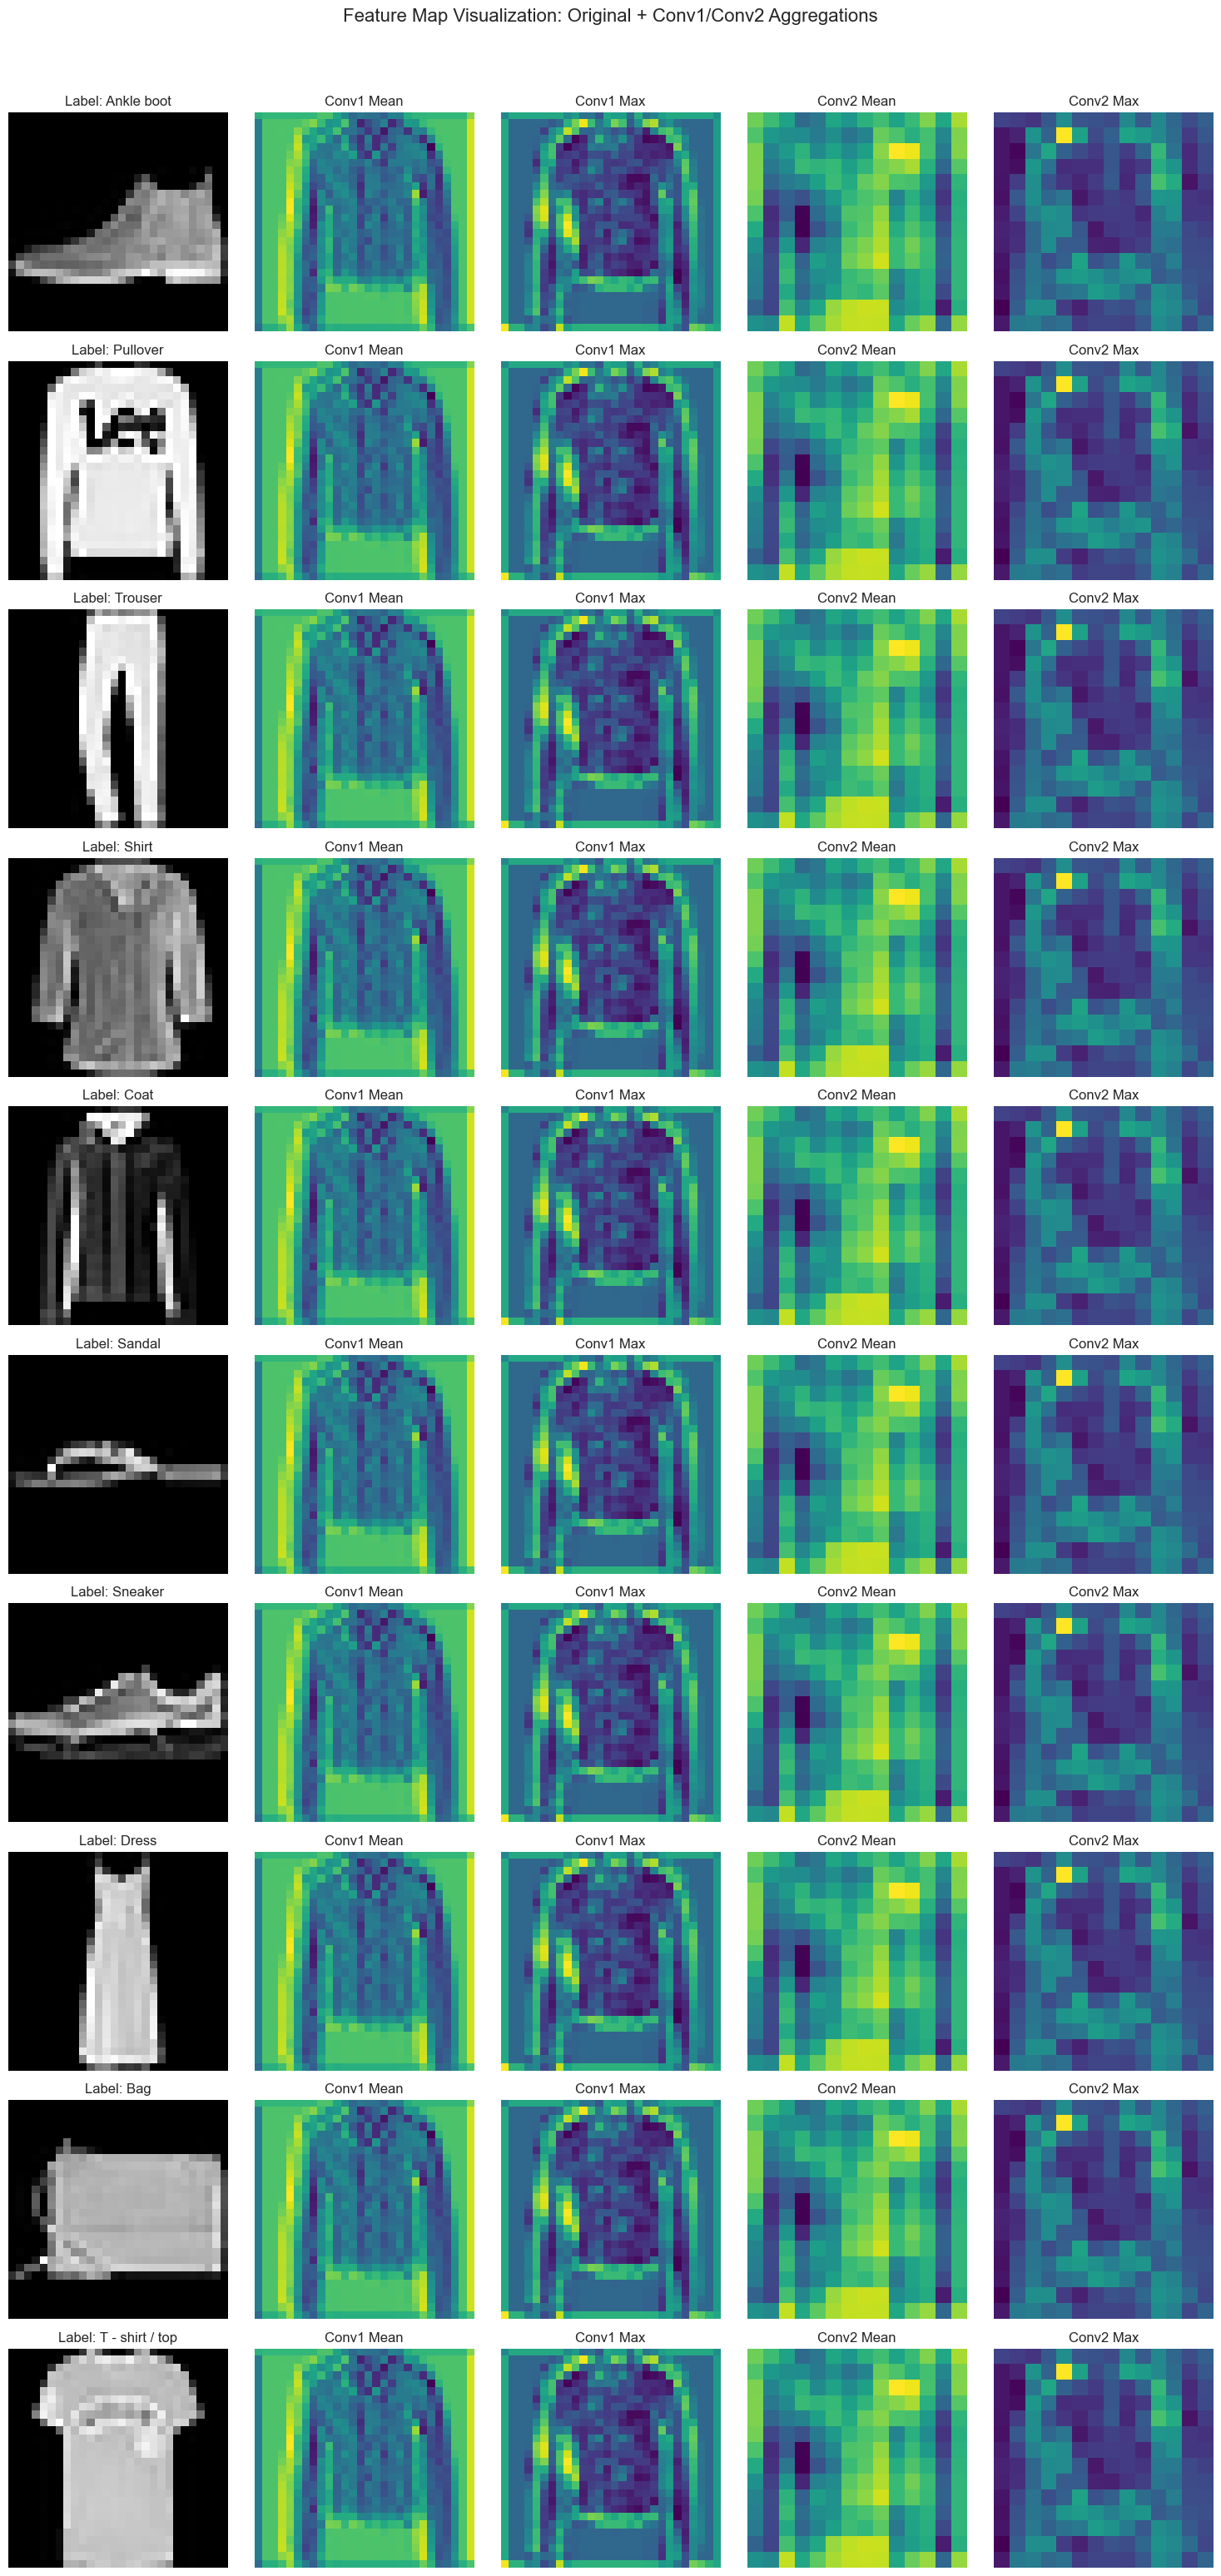

In [14]:
label_names = dataset['train'].features['label'].names
visualize_feature_maps_both_layers(model, test_dataset, label_names, samples_per_class=1, device=device)

# Remove the hook after visualization to avoid side effects
hook_handle1.remove()
hook_handle2.remove()

## What to take away

A convolution layer turns an image into internal response maps. **Try next:** Use another image or compare different layers. **Limit:** Bright areas show a filter response; they do not explain the classification by themselves.